# Multi-Class Wine Quality Classification

**Datasets:** `winequality-red.csv`, `winequality-white.csv` (UCI Wine Quality dataset)
**Target:** `quality` — every unique integer score is treated as its own class (multi-class classification, not regression, not binary good/bad)


## Notebook Organization

1. Problem Statement
2. Data Description
3. Task 1 – Load & Inspect
4. Task 2 – Data Quality Checks
5. Task 3 – Data Preparation
6. Task 4 – Logistic Regression
7. Task 5 – Random Forest
8. Task 6 – Comparative Metrics Summary
9. Task 7 – Final Conclusion


---
## Phase 1: Understand the Problem

### Step 1 — Problem Statement

We are given physicochemical lab measurements for two types of *Vinho Verde* wine (red and white) along with a `quality` score assigned by wine tasters (median of at least 3 evaluations, on a 0–10 scale). The objective is to **predict wine quality from chemical properties alone**, treating **every distinct quality value observed in the data as its own class** — i.e. a multi-class classification problem, not a regression or a binary "good/bad" task. Two separate datasets (red and white) are modeled independently so that their results can be compared.


### Step 2 — Introduction

This project addresses the problem of predicting wine quality from objective, instrument-measured chemical properties rather than relying solely on human sensory panels. Two datasets are used: `winequality-red.csv` (1,599 samples) and `winequality-white.csv` (4,898 samples), both sourced from the UCI Wine Quality repository and both sharing the same 11 physicochemical features plus the target. The target variable, `quality`, is an integer score given by wine tasters; in the red wine data it ranges from 3 to 8, and in the white wine data from 3 to 9. The 11 available features are: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol — all continuous, instrument-measured quantities. Multi-class classification is the right framing here (rather than regression) because `quality` is an ordinal but discrete, taster-assigned label, and the assignment explicitly asks us to treat each score as a separate class so we can study per-class behavior (precision/recall per quality level) rather than just an average error. As we will see, this also surfaces a real-world challenge: extreme quality scores (3, 4, 8, 9) are rare, which makes them hard for any classifier to learn — a key theme we will return to throughout this notebook.


---
## Phase 2: Load and Inspect Data

### Step 3 — Import Libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

%matplotlib inline
sns.set_style("whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


### Step 4 — Load Both Datasets

In [5]:
df_red = pd.read_csv("winequality-red.csv", sep=';')
df_white = pd.read_csv("winequality-white.csv", sep=';')

print("Red wine dataset loaded:  ", df_red.shape)
print("White wine dataset loaded:", df_white.shape)


Red wine dataset loaded:   (1599, 12)
White wine dataset loaded: (4898, 12)


### Step 5 — Inspect Both Datasets

In [6]:
print("=" * 60)
print("RED WINE")
print("=" * 60)
print("Shape:", df_red.shape)
print("\nColumn names:")
print(list(df_red.columns))
print("\nFirst five rows:")
display(df_red.head())

print("\n" + "=" * 60)
print("WHITE WINE")
print("=" * 60)
print("Shape:", df_white.shape)
print("\nColumn names:")
print(list(df_white.columns))
print("\nFirst five rows:")
display(df_white.head())


RED WINE
Shape: (1599, 12)

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First five rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



WHITE WINE
Shape: (4898, 12)

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First five rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Step 6 — Verify Target Variable

In [7]:
for name, df in [("RED", df_red), ("WHITE", df_white)]:
    n_features = df.shape[1] - 1
    n_classes = df['quality'].nunique()
    classes = sorted(df['quality'].unique())
    print(f"--- {name} ---")
    print("'quality' column present:", 'quality' in df.columns)
    print("Number of features       :", n_features)
    print("Number of target classes :", n_classes)
    print("Target classes present   :", classes)
    print()


--- RED ---
'quality' column present: True
Number of features       : 11
Number of target classes : 6
Target classes present   : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

--- WHITE ---
'quality' column present: True
Number of features       : 11
Number of target classes : 7
Target classes present   : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]



**Deliverable — written confirmation:** Both datasets contain a `quality` target column and 11 numeric features. The red wine dataset has **6** observed target classes (qualities 3–8) and the white wine dataset has **7** observed target classes (qualities 3–9). White wine therefore presents a slightly harder multi-class problem on class count alone before we even look at class balance.


---
## Phase 3: Data Quality Analysis

### Step 7 — Check Missing Values


In [8]:
print("Missing values per column — RED:")
print(df_red.isnull().sum())
print("\nTotal missing values (RED):", df_red.isnull().sum().sum())

print("\nMissing values per column — WHITE:")
print(df_white.isnull().sum())
print("\nTotal missing values (WHITE):", df_white.isnull().sum().sum())


Missing values per column — RED:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values (RED): 0

Missing values per column — WHITE:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values (WHITE): 0


### Step 8 — Check Duplicate Records

In [9]:
dup_red = df_red.duplicated().sum()
dup_white = df_white.duplicated().sum()

print(f"Duplicate rows in RED wine dataset  : {dup_red}  ({dup_red/len(df_red)*100:.2f}% of {len(df_red)} rows)")
print(f"Duplicate rows in WHITE wine dataset: {dup_white}  ({dup_white/len(df_white)*100:.2f}% of {len(df_white)} rows)")
print()
print("No rows are dropped here so that all downstream counts stay traceable to the raw files.")


Duplicate rows in RED wine dataset  : 240  (15.01% of 1599 rows)
Duplicate rows in WHITE wine dataset: 937  (19.13% of 4898 rows)

No rows are dropped here so that all downstream counts stay traceable to the raw files.


### Step 9 — Study Target Distribution

In [10]:
def class_distribution(df, name):
    counts = df['quality'].value_counts().sort_index()
    pct = (df['quality'].value_counts(normalize=True).sort_index() * 100).round(2)
    out = pd.DataFrame({'count': counts, 'percentage': pct})
    out.index.name = 'quality'
    print(f"--- {name} : quality class distribution ---")
    display(out)
    return out

dist_red = class_distribution(df_red, "RED")
dist_white = class_distribution(df_white, "WHITE")


--- RED : quality class distribution ---


,count,percentage
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13


--- WHITE : quality class distribution ---


,count,percentage
quality,,
3,20,0.41
4,163,3.33
5,1457,29.75
6,2198,44.88
7,880,17.97
8,175,3.57
9,5,0.10


### Step 10 — Plot Class Distribution

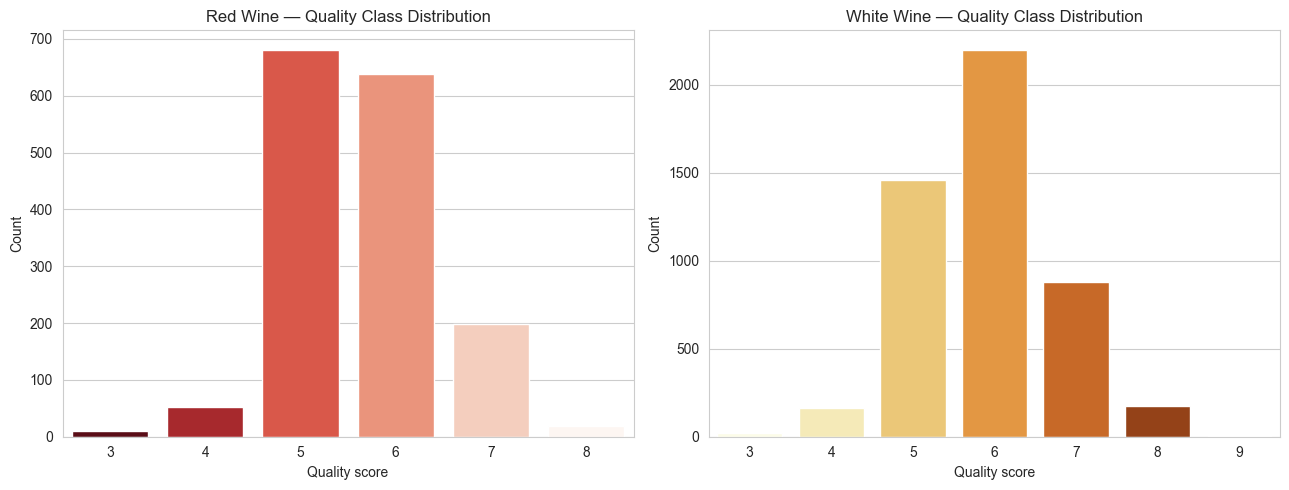

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x='quality', data=df_red, ax=axes[0], hue='quality', legend=False,
              order=sorted(df_red['quality'].unique()), palette='Reds_r')
axes[0].set_title('Red Wine — Quality Class Distribution')
axes[0].set_xlabel('Quality score')
axes[0].set_ylabel('Count')

sns.countplot(x='quality', data=df_white, ax=axes[1], hue='quality', legend=False,
              order=sorted(df_white['quality'].unique()), palette='YlOrBr')
axes[1].set_title('White Wine — Quality Class Distribution')
axes[1].set_xlabel('Quality score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Step 11 — Compare Both Datasets

**Which dataset is more imbalanced?** Looking at the majority-to-minority class ratio is more informative here than just the number of classes: in the red wine data the largest class (quality 5, 681 samples) outnumbers the smallest class (quality 3, 10 samples) by roughly **68×**. In the white wine data the largest class (quality 6, 2,198 samples) outnumbers the smallest class (quality 9, only 5 samples) by roughly **440×**. By this measure, **white wine is substantially more imbalanced** than red wine, even though red wine's two dominant classes (5 and 6) together account for a slightly larger share of the data (~82.5% vs ~74.6% for white).

**Which classes are rare?** In red wine, qualities **3** (10 samples, 0.63%) and **8** (18 samples, 1.13%) are rare. In white wine, qualities **9** (5 samples, 0.10%) and **3** (20 samples, 0.41%) are the rarest, with quality 4 (163 samples, 3.33%) also under-represented.

**Why are rare classes difficult?** With only single-digit to low double-digit examples, a classifier sees too few patterns to learn what separates, say, quality 3 from quality 4 — especially since neighboring quality scores tend to have very similar, overlapping chemical profiles (quality is an ordinal human judgment, not a clean physical boundary). Stratified train/test splitting then leaves only 1–4 test examples for these classes, so even a single misclassification swings recall dramatically (e.g. one wrong prediction on a 2-sample test class drops recall to 0% or 50%).


---
## Phase 4: Prepare Data

### Step 12 — Create X and y


In [12]:
X_red, y_red = df_red.drop(columns=['quality']), df_red['quality']
X_white, y_white = df_white.drop(columns=['quality']), df_white['quality']

print("RED   -> X:", X_red.shape,   " y:", y_red.shape)
print("WHITE -> X:", X_white.shape, " y:", y_white.shape)


RED   -> X: (1599, 11)  y: (1599,)
WHITE -> X: (4898, 11)  y: (4898,)


### Step 13 — Train-Test Split

In [13]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y_red, test_size=0.2, random_state=RANDOM_STATE, stratify=y_red
)

X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(
    X_white, y_white, test_size=0.2, random_state=RANDOM_STATE, stratify=y_white
)

print("Split complete for both datasets (test_size=0.2, random_state=42, stratify=y).")


Split complete for both datasets (test_size=0.2, random_state=42, stratify=y).


### Step 14 — Verify Split

In [14]:
for name, Xtr, Xte, ytr, yte in [
    ("RED",   X_train_red,   X_test_red,   y_train_red,   y_test_red),
    ("WHITE", X_train_white, X_test_white, y_train_white, y_test_white),
]:
    print(f"--- {name} ---")
    print("X_train shape:", Xtr.shape)
    print("X_test  shape:", Xte.shape)
    print("y_train shape:", ytr.shape)
    print("y_test  shape:", yte.shape)
    print("Train class counts:", dict(sorted(ytr.value_counts().to_dict().items())))
    print("Test  class counts:", dict(sorted(yte.value_counts().to_dict().items())))
    print()


--- RED ---
X_train shape: (1279, 11)
X_test  shape: (320, 11)
y_train shape: (1279,)
y_test  shape: (320,)
Train class counts: {3: 8, 4: 42, 5: 545, 6: 510, 7: 159, 8: 15}
Test  class counts: {3: 2, 4: 11, 5: 136, 6: 128, 7: 40, 8: 3}

--- WHITE ---
X_train shape: (3918, 11)
X_test  shape: (980, 11)
y_train shape: (3918,)
y_test  shape: (980,)
Train class counts: {3: 16, 4: 130, 5: 1166, 6: 1758, 7: 704, 8: 140, 9: 4}
Test  class counts: {3: 4, 4: 33, 5: 291, 6: 440, 7: 176, 8: 35, 9: 1}



---
## Phase 5: Model A – Logistic Regression

### Red Wine


**Step 15 — Build Pipeline (Red)**

In [15]:
pipe_lr_red = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000))
])
pipe_lr_red


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

**Step 16–17 — Train Model & Predict (Red)**

In [16]:
pipe_lr_red.fit(X_train_red, y_train_red)
pred_lr_red = pipe_lr_red.predict(X_test_red)
print("Logistic Regression trained on RED wine. Predictions generated for", len(pred_lr_red), "test samples.")


Logistic Regression trained on RED wine. Predictions generated for 320 test samples.


**Step 18 — Evaluate (Red)**

Accuracy      : 0.5906
Macro F1-score: 0.2776

Classification Report (RED, Logistic Regression):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



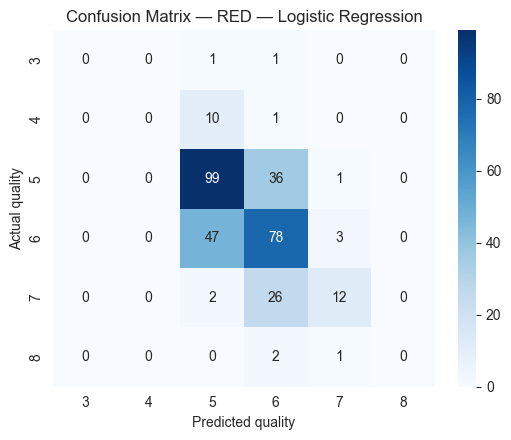

In [17]:
acc_lr_red = accuracy_score(y_test_red, pred_lr_red)
f1_lr_red = f1_score(y_test_red, pred_lr_red, average='macro')
labels_red = sorted(y_red.unique())

print(f"Accuracy      : {acc_lr_red:.4f}")
print(f"Macro F1-score: {f1_lr_red:.4f}")
print("\nClassification Report (RED, Logistic Regression):")
print(classification_report(y_test_red, pred_lr_red, labels=labels_red, zero_division=0))

cm_lr_red = confusion_matrix(y_test_red, pred_lr_red, labels=labels_red)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_lr_red, annot=True, fmt='d', cmap='Blues', xticklabels=labels_red, yticklabels=labels_red)
plt.title('Confusion Matrix — RED — Logistic Regression')
plt.xlabel('Predicted quality')
plt.ylabel('Actual quality')
plt.tight_layout()
plt.show()


### White Wine

**Step 15 — Build Pipeline (White)**

In [18]:
pipe_lr_white = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000))
])
pipe_lr_white


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

**Step 16–17 — Train Model & Predict (White)**

In [19]:
pipe_lr_white.fit(X_train_white, y_train_white)
pred_lr_white = pipe_lr_white.predict(X_test_white)
print("Logistic Regression trained on WHITE wine. Predictions generated for", len(pred_lr_white), "test samples.")


Logistic Regression trained on WHITE wine. Predictions generated for 980 test samples.


**Step 18 — Evaluate (White)**

Accuracy      : 0.5490
Macro F1-score: 0.2367

Classification Report (WHITE, Logistic Regression):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



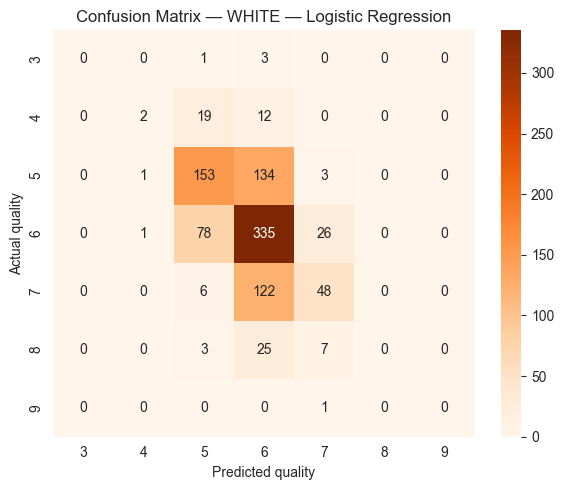

In [20]:
acc_lr_white = accuracy_score(y_test_white, pred_lr_white)
f1_lr_white = f1_score(y_test_white, pred_lr_white, average='macro')
labels_white = sorted(y_white.unique())

print(f"Accuracy      : {acc_lr_white:.4f}")
print(f"Macro F1-score: {f1_lr_white:.4f}")
print("\nClassification Report (WHITE, Logistic Regression):")
print(classification_report(y_test_white, pred_lr_white, labels=labels_white, zero_division=0))

cm_lr_white = confusion_matrix(y_test_white, pred_lr_white, labels=labels_white)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr_white, annot=True, fmt='d', cmap='Oranges', xticklabels=labels_white, yticklabels=labels_white)
plt.title('Confusion Matrix — WHITE — Logistic Regression')
plt.xlabel('Predicted quality')
plt.ylabel('Actual quality')
plt.tight_layout()
plt.show()


### Step 19 — Interpret Results

**Which dataset performed better?** Logistic Regression performs better on the **red** wine dataset on both metrics (Accuracy: 0.5906 vs 0.5490; Macro F1: 0.2776 vs 0.2367). This is consistent with red wine having one fewer class and a more concentrated majority.

**Which quality class has the lowest recall?** In both datasets, the most extreme minority classes have **0.00 recall** — quality 3, 4 and 8 in red wine, and quality 3, 8 and 9 in white wine all score 0.00 recall with this linear model (quality 4 in white wine is only slightly better, at 0.06). Quality **3** is the single most consistent failure point across both datasets: a linear decision boundary, fit on a handful of examples buried among thousands of mid-range wines, essentially never recovers it.


---
## Phase 6: Model B – Random Forest

### Red Wine


**Step 20 — Build Random Forest (Red)**

In [21]:
rf_red = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_red


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Step 21–22 — Train Model & Predict (Red)**

In [22]:
rf_red.fit(X_train_red, y_train_red)
pred_rf_red = rf_red.predict(X_test_red)
print("Random Forest trained on RED wine. Predictions generated for", len(pred_rf_red), "test samples.")


Random Forest trained on RED wine. Predictions generated for 320 test samples.


**Step 23 — Evaluate (Red)**

Accuracy      : 0.6813
Macro F1-score: 0.4094

Classification Report (RED, Random Forest):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



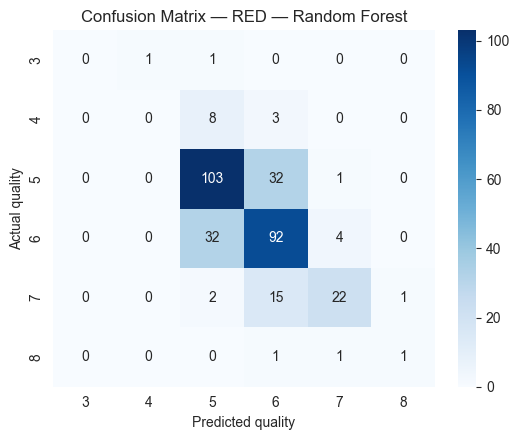

In [23]:
acc_rf_red = accuracy_score(y_test_red, pred_rf_red)
f1_rf_red = f1_score(y_test_red, pred_rf_red, average='macro')

print(f"Accuracy      : {acc_rf_red:.4f}")
print(f"Macro F1-score: {f1_rf_red:.4f}")
print("\nClassification Report (RED, Random Forest):")
print(classification_report(y_test_red, pred_rf_red, labels=labels_red, zero_division=0))

cm_rf_red = confusion_matrix(y_test_red, pred_rf_red, labels=labels_red)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_rf_red, annot=True, fmt='d', cmap='Blues', xticklabels=labels_red, yticklabels=labels_red)
plt.title('Confusion Matrix — RED — Random Forest')
plt.xlabel('Predicted quality')
plt.ylabel('Actual quality')
plt.tight_layout()
plt.show()


### White Wine

**Step 20 — Build Random Forest (White)**

In [24]:
rf_white = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_white


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Step 21–22 — Train Model & Predict (White)**

In [25]:
rf_white.fit(X_train_white, y_train_white)
pred_rf_white = rf_white.predict(X_test_white)
print("Random Forest trained on WHITE wine. Predictions generated for", len(pred_rf_white), "test samples.")


Random Forest trained on WHITE wine. Predictions generated for 980 test samples.


**Step 23 — Evaluate (White)**

Accuracy      : 0.6724
Macro F1-score: 0.4222

Classification Report (WHITE, Random Forest):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



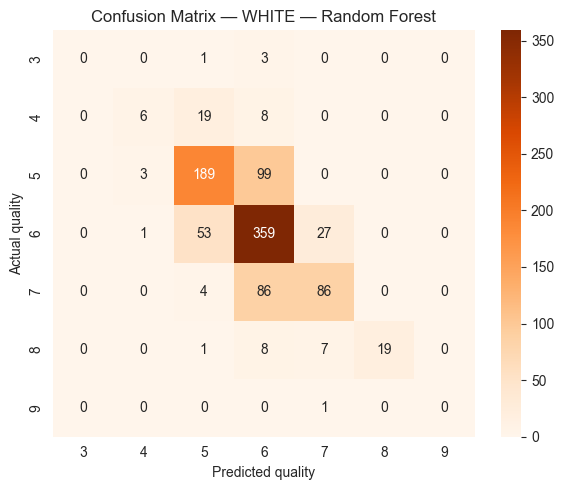

In [26]:
acc_rf_white = accuracy_score(y_test_white, pred_rf_white)
f1_rf_white = f1_score(y_test_white, pred_rf_white, average='macro')

print(f"Accuracy      : {acc_rf_white:.4f}")
print(f"Macro F1-score: {f1_rf_white:.4f}")
print("\nClassification Report (WHITE, Random Forest):")
print(classification_report(y_test_white, pred_rf_white, labels=labels_white, zero_division=0))

cm_rf_white = confusion_matrix(y_test_white, pred_rf_white, labels=labels_white)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_white, annot=True, fmt='d', cmap='Oranges', xticklabels=labels_white, yticklabels=labels_white)
plt.title('Confusion Matrix — WHITE — Random Forest')
plt.xlabel('Predicted quality')
plt.ylabel('Actual quality')
plt.tight_layout()
plt.show()


### Step 24 — Compare with Logistic Regression

**Did Random Forest improve?** Yes, substantially, on **both** datasets and **both** metrics:

| Dataset | Metric | Logistic Regression | Random Forest | Change |
|---|---|---|---|---|
| Red   | Accuracy  | 0.5906 | 0.6813 | +0.0907 |
| Red   | Macro F1  | 0.2776 | 0.4094 | +0.1318 |
| White | Accuracy  | 0.5490 | 0.6724 | +0.1234 |
| White | Macro F1  | 0.2367 | 0.4222 | +0.1855 |

The non-linear, tree-based ensemble captures the overlapping, non-linear relationships between chemistry and taster quality far better than a linear decision boundary — and the gain in *macro* F1 (which weights every class equally) is even larger than the gain in raw accuracy, showing Random Forest is specifically better at the minority classes, not just the easy majority ones.

**Which class remains difficult?** Quality **3** remains effectively unsolved by Random Forest in both datasets (0.00 recall in red; 0.00 recall in white), and quality **9** in white wine (a single test sample) is also unrecoverable. Quality 4 improves somewhat (red: still 0.00 recall; white: recall rises from 0.06 to 0.18) but is still far below the mid-range classes. The pattern is consistent: **no amount of model sophistication can fully compensate for classes with only a handful of training examples** — more data or a different problem framing (see Final Conclusion) is needed for those classes specifically.


---
## Phase 7: Comparative Study

### Step 25 — Comparison Table


In [27]:
comparison_table = pd.DataFrame([
    {
        "Dataset": "Red",
        "Model": "Logistic Regression",
        "Accuracy": round(acc_lr_red, 4),
        "Macro F1-score": round(f1_lr_red, 4),
        "Observation": "Moderate accuracy driven by majority classes 5 & 6; zero recall on classes 3, 4, 8."
    },
    {
        "Dataset": "Red",
        "Model": "Random Forest",
        "Accuracy": round(acc_rf_red, 4),
        "Macro F1-score": round(f1_rf_red, 4),
        "Observation": "Best result for red wine; clear lift over Logistic Regression; class 3 & 4 still unresolved."
    },
    {
        "Dataset": "White",
        "Model": "Logistic Regression",
        "Accuracy": round(acc_lr_white, 4),
        "Macro F1-score": round(f1_lr_white, 4),
        "Observation": "Weakest overall result; 7 overlapping classes are too much for a linear boundary."
    },
    {
        "Dataset": "White",
        "Model": "Random Forest",
        "Accuracy": round(acc_rf_white, 4),
        "Macro F1-score": round(f1_rf_white, 4),
        "Observation": "Highest macro F1-score of all four runs; classes 3 & 9 remain essentially unlearnable."
    },
])
display(comparison_table)


,Dataset,Model,Accuracy,Macro F1-score,Observation
0,Red,Logistic Regression,0.5906,0.2776,Moderate accuracy driven by majority classes 5...
1,Red,Random Forest,0.6813,0.4094,Best result for red wine; clear lift over Logi...
2,White,Logistic Regression,0.5490,0.2367,Weakest overall result; 7 overlapping classes ...
3,White,Random Forest,0.6724,0.4222,Highest macro F1-score of all four runs; class...


### Step 26 — Display Supporting Outputs

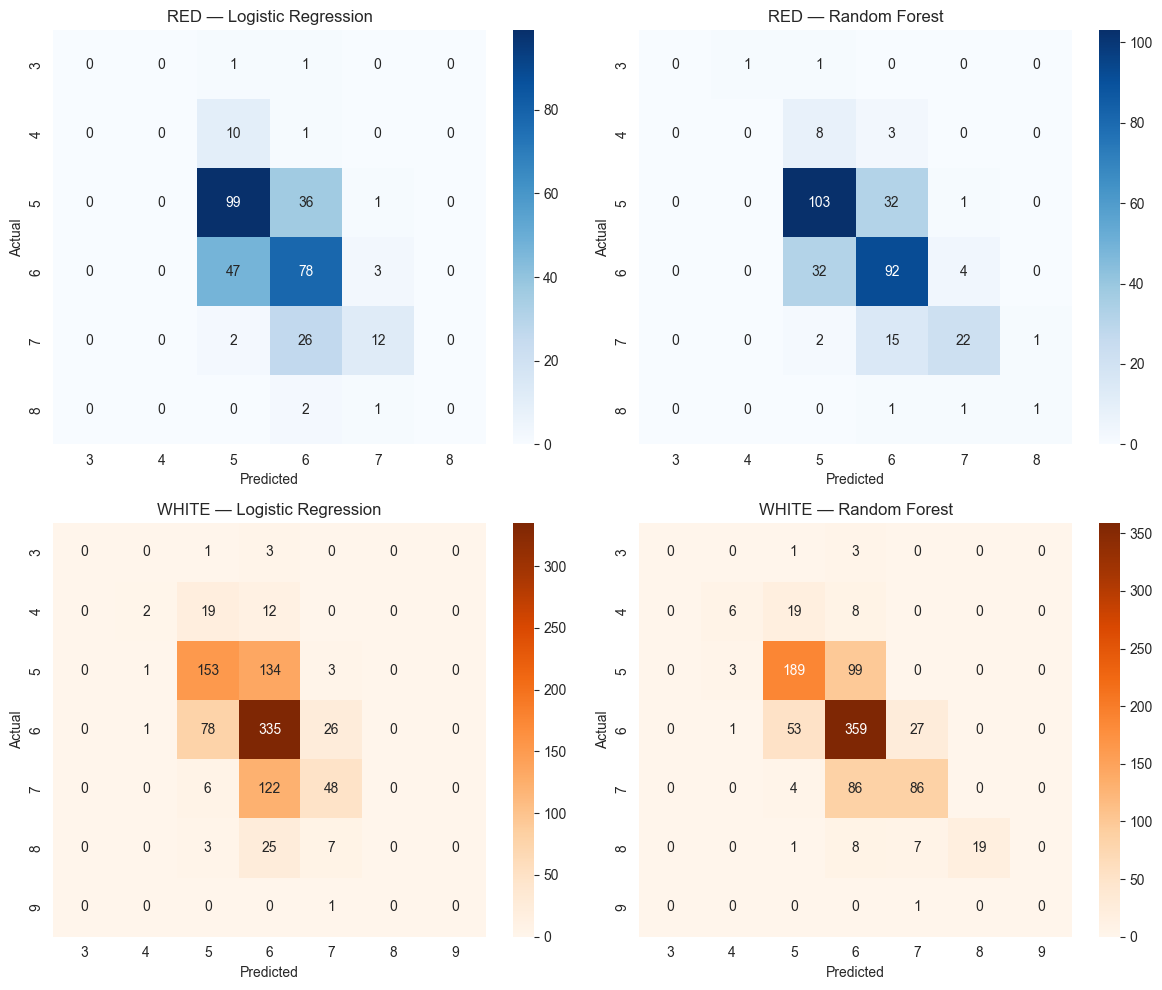

In [28]:
# Four confusion matrices, side by side for direct comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(cm_lr_red, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=labels_red, yticklabels=labels_red)
axes[0, 0].set_title('RED — Logistic Regression')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')

sns.heatmap(cm_rf_red, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=labels_red, yticklabels=labels_red)
axes[0, 1].set_title('RED — Random Forest')
axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')

sns.heatmap(cm_lr_white, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0],
            xticklabels=labels_white, yticklabels=labels_white)
axes[1, 0].set_title('WHITE — Logistic Regression')
axes[1, 0].set_xlabel('Predicted'); axes[1, 0].set_ylabel('Actual')

sns.heatmap(cm_rf_white, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            xticklabels=labels_white, yticklabels=labels_white)
axes[1, 1].set_title('WHITE — Random Forest')
axes[1, 1].set_xlabel('Predicted'); axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [29]:
# Four classification reports, consolidated for easy side-by-side reading
print("#" * 70)
print("# RED — Logistic Regression")
print("#" * 70)
print(classification_report(y_test_red, pred_lr_red, labels=labels_red, zero_division=0))

print("#" * 70)
print("# RED — Random Forest")
print("#" * 70)
print(classification_report(y_test_red, pred_rf_red, labels=labels_red, zero_division=0))

print("#" * 70)
print("# WHITE — Logistic Regression")
print("#" * 70)
print(classification_report(y_test_white, pred_lr_white, labels=labels_white, zero_division=0))

print("#" * 70)
print("# WHITE — Random Forest")
print("#" * 70)
print(classification_report(y_test_white, pred_rf_white, labels=labels_white, zero_division=0))


######################################################################
# RED — Logistic Regression
######################################################################
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320

######################################################################
# RED — Random Forest
######################################################################
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4  

### Step 27 — Comparative Analysis

**Best dataset:** This depends on the metric. Red wine yields the **highest raw accuracy** with Random Forest (0.6813), reflecting its smaller class count and stronger concentration in classes 5–6. White wine, however, yields the **highest macro F1-score** with Random Forest (0.4222 vs 0.4094 for red) — meaning that, *averaged equally across all of its classes*, the white wine Random Forest model is the most balanced performer of the four runs, even though it is solving a harder 7-class problem.

**Best model:** **Random Forest**, unambiguously — it improves both accuracy and macro F1 on both datasets, with no exceptions.

**Reasons:** Wine quality depends on non-linear interactions between chemical properties (e.g. the effect of alcohol on perceived quality differs depending on acidity and sulphates), which tree ensembles capture naturally through axis-aligned splits and feature interactions, while Logistic Regression is constrained to (regularized) linear combinations of the scaled features.

**Difficult quality classes:** Across all four model/dataset combinations, quality **3** is the most persistently difficult class (0.00 recall in 3 of the 4 runs, and 0.00 in red Random Forest too), followed by quality **4** and, for white wine specifically, quality **9** (a single test example). These are exactly the classes identified as rare in Step 11 — the difficulty is a direct, traceable consequence of data scarcity, not a model weakness.


---
## Phase 8: Final Conclusion

Taken together, the **red wine dataset was the easier classification task** when judged by raw accuracy (its 6-class structure and ~82.5% concentration in two dominant classes give every model an easier job), but the **white wine dataset's Random Forest model was the more balanced performer** by macro F1-score, despite working with one extra class and a more extreme minority class. The clear **best model overall was Random Forest**, which beat Logistic Regression on every metric, on every dataset, with no exceptions — confirming that the relationship between wine chemistry and perceived quality is non-linear enough that a linear classifier consistently under-fits it. The **most confusing quality scores** were the rare extremes — 3, 4, 8 (and 9 in white wine) — which were frequently misclassified into the neighboring majority classes (5 and 6) simply because there were too few training examples to learn what makes them distinct, compounded by the fact that adjacent quality scores have genuinely overlapping chemical profiles (quality is a human sensory judgment, not a sharp physical boundary). The single **most promising improvement to try next** is to **convert the problem into 3 broader bands** (e.g. low ≤5, medium =6, high ≥7) — this directly attacks the root cause (data scarcity in the extreme classes) by merging them into categories with enough examples to learn from, rather than asking the model to distinguish between classes that have 5–20 training examples. `class_weight="balanced"` and hyperparameter tuning (e.g. `GridSearchCV` over `max_depth`, `min_samples_leaf`, `n_estimators`) are reasonable secondary options, but neither one manufactures more training examples for quality 3 or 9 — only re-binning the target does that.
